# QPSK over an AWGN channel

This notebook studies Gray-coded quadrature phase-shift keying (QPSK) with `pyberlab`. It visualises the four-point constellation, explains the independent in-phase and quadrature decisions, verifies the theoretical relationship with BPSK, and runs a reproducible BER experiment.

## System model

Each QPSK symbol carries two bits, one on each orthogonal component:

$$x = \frac{(2b_I-1) + j(2b_Q-1)}{\sqrt{2}}. $$

The $1/\sqrt{2}$ scale gives unit average symbol energy. Since $E_b=E_s/2$, each I/Q branch behaves like an independent BPSK channel at the same $E_b/N_0$. Gray-coded QPSK therefore has

$$P_b = \frac{1}{2}\operatorname{erfc}\!\left(\sqrt{E_b/N_0}\right),$$

which is the same bit-error probability as coherent BPSK.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "pyberlab").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the pyberlab repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pyberlab.channel import awgn
from pyberlab.modulation import QPSK
from pyberlab.plot import plot_ber
from pyberlab.simulation import run_simulation
from pyberlab.theory import bpsk_awgn, qpsk_awgn

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / "qpsk_awgn_notebook.csv"
FIGURE_PATH = OUTPUT_DIR / "qpsk_awgn_notebook.png"
SEED = 42
EBN0_DB = np.arange(0, 11)

print("Results will be saved in: outputs/")

Results will be saved in: outputs/


## Inspect the Gray-coded constellation

The axes are also the hard-decision boundaries. Moving between horizontally or vertically adjacent points changes only one bit.

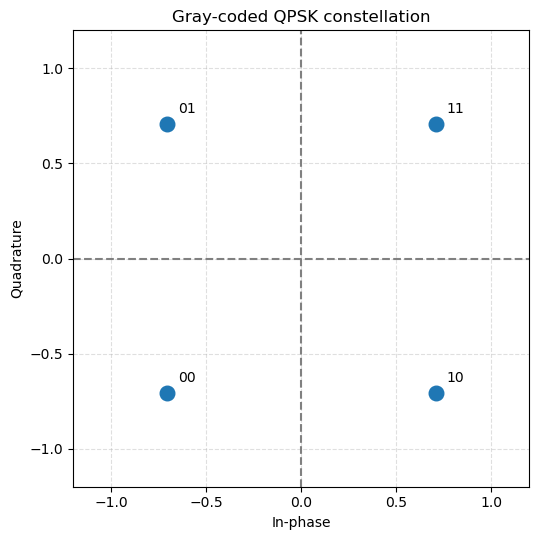

Average symbol power: 1.000


In [3]:
modulator = QPSK()
bit_pairs = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
constellation = modulator.modulate(bit_pairs.flatten())

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(constellation.real, constellation.imag, s=110)
for pair, symbol in zip(bit_pairs, constellation):
    label = "".join(str(bit) for bit in pair)
    ax.annotate(label, (symbol.real, symbol.imag), xytext=(8, 8), textcoords="offset points")
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(0, color="gray", linestyle="--")
ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), xlabel="In-phase", ylabel="Quadrature", title="Gray-coded QPSK constellation")
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

print(f"Average symbol power: {np.mean(np.abs(constellation) ** 2):.3f}")

## Verify the BPSK/QPSK theory relationship

The library exposes separate theory functions for dispatch clarity. Numerically, they must be identical when compared at the same $E_b/N_0$.

In [4]:
ebn0_linear = 10 ** (EBN0_DB / 10)
bpsk_theory = bpsk_awgn(ebn0_linear)
qpsk_theory = qpsk_awgn(ebn0_linear)
np.testing.assert_allclose(qpsk_theory, bpsk_theory)
print(f"Maximum BPSK/QPSK theory difference: {np.max(np.abs(qpsk_theory - bpsk_theory)):.1e}")

Maximum BPSK/QPSK theory difference: 0.0e+00


## Run the BER experiment

The runner targets at least 200 expected bit errors at each SNR point. A two-million-bit cap bounds the high-SNR runtime, and the fixed seed makes every result reproducible.

In [5]:
results = run_simulation(
    modulator,
    awgn,
    EBN0_DB,
    seed=SEED,
    min_errors=200,
    max_bits=2_000_000,
    csv_path=CSV_PATH,
)

print(f"Saved {len(results['EbN0_dB'])} SNR points to {CSV_PATH.relative_to(PROJECT_ROOT)}")

Saved 11 SNR points to outputs\qpsk_awgn_notebook.csv


In [6]:
print(f"{'Eb/N0 (dB)':>10} {'BER sim':>13} {'BER theory':>13} {'bits':>11} {'errors':>8}")
print("-" * 61)
for ebn0, simulated, theoretical, n_bits, n_errors in zip(
    results["EbN0_dB"],
    results["ber_sim"],
    results["ber_theory"],
    results["n_bits"],
    results["n_errors"],
):
    print(f"{ebn0:10.1f} {simulated:13.6g} {theoretical:13.6g} {n_bits:11,d} {n_errors:8,d}")

Eb/N0 (dB)       BER sim    BER theory        bits   errors
-------------------------------------------------------------
       0.0       0.07906     0.0786496     100,000    7,906
       1.0       0.05631      0.056282     100,000    5,631
       2.0       0.03751     0.0375061     100,000    3,751
       3.0       0.02244     0.0228784     100,000    2,244
       4.0       0.01217     0.0125008     100,000    1,217
       5.0       0.00613    0.00595387     100,000      613
       6.0       0.00226    0.00238829     100,000      226
       7.0   0.000676093   0.000772675     258,840      175
       8.0   0.000205226   0.000190908   1,047,626      215
       9.0       4.1e-05   3.36272e-05   2,000,000       82
      10.0       4.5e-06   3.87211e-06   2,000,000        9


## Check statistical agreement

The difference between simulation and theory is measured in binomial standard errors. High-SNR estimates vary more because the bit cap may be reached before 200 errors occur.

In [7]:
ber_sim = np.asarray(results["ber_sim"])
ber_theory = np.asarray(results["ber_theory"])
n_bits = np.asarray(results["n_bits"])
standard_error = np.sqrt(ber_theory * (1 - ber_theory) / n_bits)
z_scores = np.abs(ber_sim - ber_theory) / standard_error

print(f"Largest simulation/theory difference: {z_scores.max():.2f} standard errors")
print(f"Mean absolute BER difference: {np.mean(np.abs(ber_sim - ber_theory)):.3e}")

Largest simulation/theory difference: 1.80 standard errors
Mean absolute BER difference: 1.486e-04


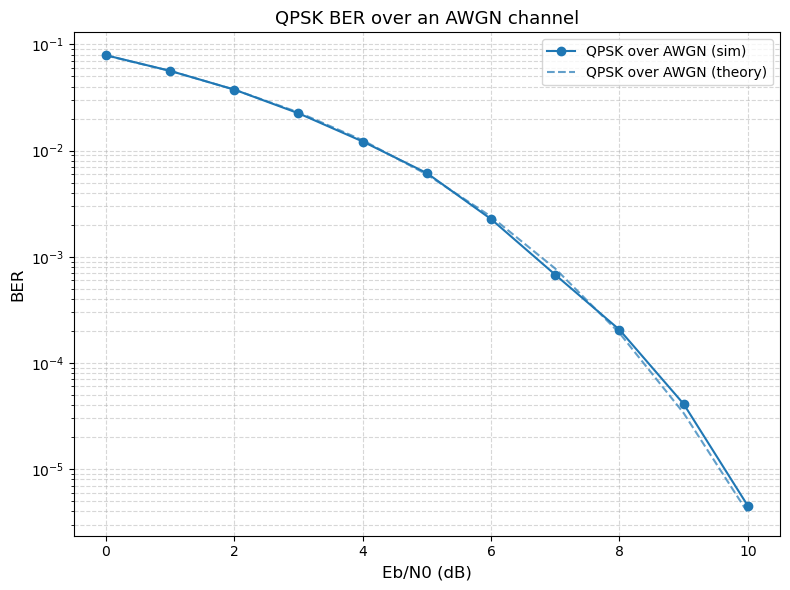

Saved figure to outputs\qpsk_awgn_notebook.png


In [8]:
plot_ber(
    [results],
    ["QPSK over AWGN"],
    title="QPSK BER over an AWGN channel",
    save_path=FIGURE_PATH,
    show=False,
)
plt.show()
print(f"Saved figure to {FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## Interpretation

The simulated QPSK markers should track the analytical curve. At a fixed $E_b/N_0$, QPSK achieves the same BER as BPSK while carrying two bits per complex symbol. This is a spectral-efficiency advantage, not an energy-per-bit advantage.

### Suggested experiments

- Change `SEED` to observe Monte-Carlo variation.
- Increase `max_bits` and inspect the high-SNR points.
- Run BPSK and QPSK together and compare BER against symbol rate.
- Replace `awgn` with `rayleigh` to study flat fading.